# Farm-mapping experiment results

Analysis of every experiment that has **finished**: the 20-run GPU ablation fleet
plus the seven post-hoc experiments run on archived model outputs.

The organising idea: **a delta only means something relative to run-to-run
variance.** Section 1 measures that variance; everything after is judged against it.

| Source | What |
|---|---|
| `experiments/gpu_results/<run>/` | per-run metrics + scored parquet (20 runs) |
| `experiments/results/*.json` | post-hoc experiment outputs |
| `experiments/results/gpu_runs_analysis.json` | precomputed lever verdicts |

Regenerate with `python3 experiments/build_notebook.py`.

In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "experiments"))
RES  = REPO / "experiments" / "results"
GPU  = REPO / "experiments" / "gpu_results"

# --- validated palette (dataviz reference instance, first three categorical
# --- slots + the blue<->red diverging pair; see references/palette.md)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GOOD, CRITICAL     = "#0ca30c", "#d03b3b"
NEUTRAL            = "#f0efec"
INK, INK2, MUTED   = "#0b0b0b", "#52514e", "#8a8984"

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110,
})

def load(name):
    p = RES / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None

A = load("gpu_runs_analysis")
print(f"runs collected: {len(list(GPU.glob('*/training_metrics.json')))}")
print(f"frozen benchmark: {A['frozen_n']:,} rows | seed sigma (AUC) = {A['sigma_auc']:.5f}")

runs collected: 20
frozen benchmark: 11,365 rows | seed sigma (AUC) = 0.00076


## 1. Seed variance — the calibration for everything else

Five runs of the **identical** configuration, differing only in the random seed.
Whatever spread appears here is the noise floor: any lever moving a metric by less
than this is unmeasurable, regardless of how it was reported historically.

In [2]:
SLICES = [("training_metrics.json", "test"), ("eval_metrics.json", "eval"),
          ("generalization_metrics.json", "gen"), ("qual_eval_metrics.json", "qual_eval")]
SEED_RUNS = {42: None, 43: "e03_seed43", 44: "e03_seed44", 45: "e03_seed45", 46: "e03_seed46"}
CACHE = REPO / "notebooks" / "results_cache" / "data" / "output" / "world_v10_fourclass_v9"

def slice_metrics(run):
    # macro-F1 per slice for a run; run=None is the archived production baseline
    base = CACHE if run is None else GPU / run
    out = {}
    for fname, key in SLICES:
        p = base / fname
        if p.exists():
            j = json.loads(p.read_text())
            out[key] = j.get("f1")
            out[key + "_cls"] = [j.get(f"f1_class{i}") for i in range(4)]
    return out

seed_rows = []
for seed, run in SEED_RUNS.items():
    m = slice_metrics(run)
    seed_rows.append({"seed": seed, "run": run or "production (42)",
                      **{k: v for k, v in m.items() if not k.endswith("_cls")}})
seeds = pd.DataFrame(seed_rows).set_index("seed")
display(seeds.style.format({c: "{:.4f}" for c in ["test","eval","gen","qual_eval"]}))

sigma = seeds[["test","eval","gen","qual_eval"]].std(ddof=1)
print("\nseed sigma (macro-F1):")
for k, v in sigma.items():
    print(f"  {k:<10} {v:.4f}   decision band for two single runs (2*sqrt2*sigma) = +/-{2*np.sqrt(2)*v:.4f}")

,run,test,eval,gen,qual_eval
seed,,,,,
42,production (42),0.8030,0.6023,0.3940,0.6330
43,e03_seed43,0.7992,0.6830,0.4126,0.6785
44,e03_seed44,0.7999,0.6266,0.3966,0.6519
45,e03_seed45,0.8130,0.6746,0.3961,0.6517
46,e03_seed46,0.8005,0.6472,0.4008,0.6507



seed sigma (macro-F1):
  test       0.0057   decision band for two single runs (2*sqrt2*sigma) = +/-0.0161
  eval       0.0334   decision band for two single runs (2*sqrt2*sigma) = +/-0.0946
  gen        0.0075   decision band for two single runs (2*sqrt2*sigma) = +/-0.0211
  qual_eval  0.0163   decision band for two single runs (2*sqrt2*sigma) = +/-0.0460


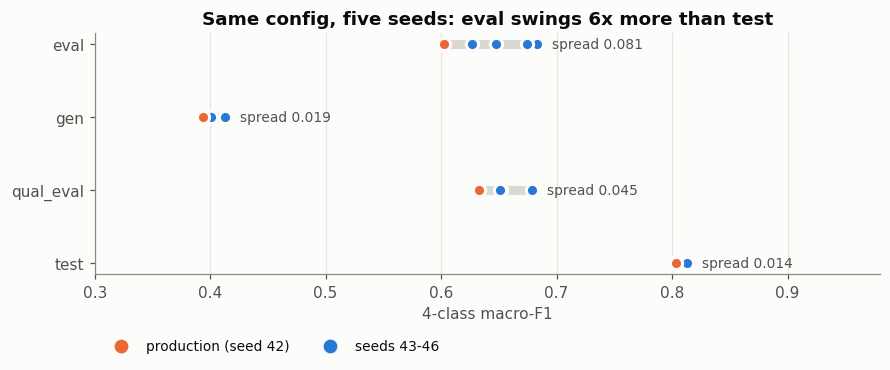

In [3]:
# Form: dot plot. The job is spread-around-a-centre per slice, and with 5 points
# per slice individual runs matter -- a bar would hide them behind a mean.
fig, ax = plt.subplots(figsize=(8.2, 3.6))
order = ["test", "qual_eval", "gen", "eval"]
for i, sl in enumerate(order):
    vals = seeds[sl].to_numpy(dtype=float)
    ax.plot([vals.min(), vals.max()], [i, i], color="#d9d8d3", lw=6,
            solid_capstyle="round", zorder=1)
    ax.scatter(vals, [i]*len(vals), s=64, color=BLUE, zorder=3,
               edgecolor="#fcfcfb", linewidth=2)
    ax.scatter([vals[0]], [i], s=64, color=ORANGE, zorder=4,
               edgecolor="#fcfcfb", linewidth=2)
    ax.annotate(f"spread {vals.max()-vals.min():.3f}", (vals.max(), i),
                xytext=(10, 0), textcoords="offset points", va="center",
                fontsize=9, color=INK2)

ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_xlabel("4-class macro-F1"); ax.set_xlim(0.30, 0.98)
ratio = (seeds["eval"].max()-seeds["eval"].min()) / (seeds["test"].max()-seeds["test"].min())
ax.set_title(f"Same config, five seeds: eval swings {ratio:.0f}x more than test")
ax.grid(axis="y", visible=False)
handles = [plt.Line2D([], [], marker="o", ls="", color=ORANGE, markersize=8, label="production (seed 42)"),
           plt.Line2D([], [], marker="o", ls="", color=BLUE, markersize=8, label="seeds 43-46")]
ax.legend(handles=handles, frameon=False, fontsize=9,
          loc="upper left", bbox_to_anchor=(0.0, -0.22), ncol=2)
plt.tight_layout(); plt.show()

**Read this against the project's historical verdicts.** The eval slice — the metric
most decisions were made on — has σ ≈ 0.033, so a comparison between two single runs
carries a decision band of roughly **±0.095**.

In [4]:
history = pd.DataFrame([
    ("Class-balanced sampling helps in-domain", 0.046),
    ("v10 regularizer bundle helps eval",       0.057),
    ("SoftCon beats SSL4EO",                    0.015),
    ("Round-3 label expansion",                 0.000),
], columns=["historical verdict", "reported delta (eval)"])
s_eval = sigma["eval"]
history["delta / sigma"] = history["reported delta (eval)"] / s_eval
history["status"] = np.where(history["reported delta (eval)"].abs() > 2*np.sqrt(2)*s_eval,
                             "separates", "WITHIN NOISE")
display(history.style.format({"reported delta (eval)": "{:+.3f}", "delta / sigma": "{:+.1f}"}))

,historical verdict,reported delta (eval),delta / sigma,status
0,Class-balanced sampling helps in-domain,+0.046,+1.4,WITHIN NOISE
1,v10 regularizer bundle helps eval,+0.057,+1.7,WITHIN NOISE
2,SoftCon beats SSL4EO,+0.015,+0.4,WITHIN NOISE
3,Round-3 label expansion,+0.000,+0.0,WITHIN NOISE


## 2. Where the noise comes from: one nearly-empty class

Macro-F1 averages the four classes equally, so a class with a handful of held-out
rows can move the headline number more than the model's behaviour actually moved.

In [5]:
CLASSES = ["NotFarm", "Poultry", "Pigs", "Cattle"]
SUPPORT = {"eval": [135, 319, 62, 7], "qual_eval": [9676, 1852, 282, 6], "test": [425, 1344, 300, 25]}

rows = []
for sl in ["eval", "qual_eval", "test"]:
    per_class = np.array([slice_metrics(r).get(sl + "_cls") for r in SEED_RUNS.values()], dtype=float)
    macro = np.array([slice_metrics(r).get(sl) for r in SEED_RUNS.values()], dtype=float)
    rows.append({"slice": sl, "class": "macro-F1", "spread": macro.max()-macro.min(), "support": np.nan})
    for ci, cname in enumerate(CLASSES):
        rows.append({"slice": sl, "class": cname,
                     "spread": np.nanmax(per_class[:, ci]) - np.nanmin(per_class[:, ci]),
                     "support": SUPPORT[sl][ci]})
spread = pd.DataFrame(rows)
display(spread.pivot(index="class", columns="slice", values="spread")
              .reindex(["macro-F1"] + CLASSES).style.format("{:.3f}", na_rep="-"))

slice,eval,qual_eval,test
class,,,
macro-F1,0.081,0.045,0.014
NotFarm,0.029,0.003,0.008
Poultry,0.022,0.009,0.003
Pigs,0.075,0.040,0.025
Cattle,0.200,0.150,0.038


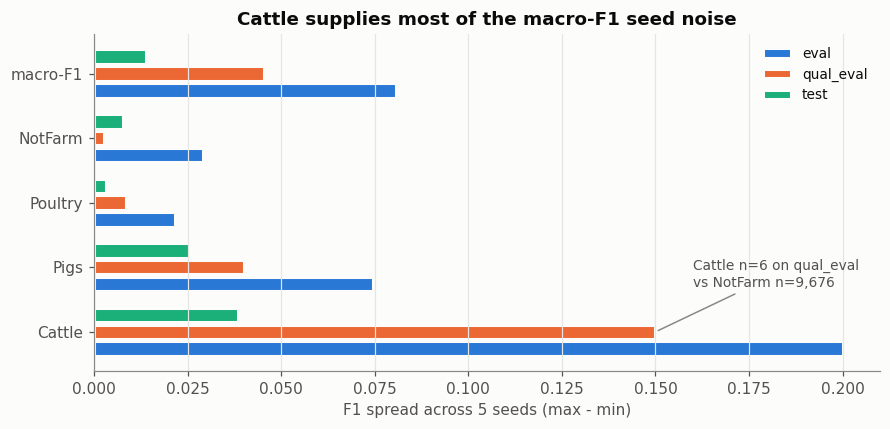

In [6]:
# Form: grouped horizontal bars. Job is magnitude comparison across a small
# categorical set; horizontal keeps the class labels readable.
fig, ax = plt.subplots(figsize=(8.2, 4.0))
show = ["macro-F1"] + CLASSES
sl_order = ["eval", "qual_eval", "test"]
colors = {"eval": BLUE, "qual_eval": ORANGE, "test": AQUA}
h = 0.26
for j, sl in enumerate(sl_order):
    vals = [spread[(spread["slice"] == sl) & (spread["class"] == c)]["spread"].iloc[0] for c in show]
    ypos = np.arange(len(show)) - (j - 1) * h
    ax.barh(ypos, vals, height=h*0.86, color=colors[sl], label=sl,
            edgecolor="#fcfcfb", linewidth=2)

ax.set_yticks(np.arange(len(show))); ax.set_yticklabels(show)
ax.invert_yaxis()
ax.set_xlabel("F1 spread across 5 seeds (max - min)")
ax.set_title("Cattle supplies most of the macro-F1 seed noise")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, fontsize=9)
ax.annotate("Cattle n=6 on qual_eval\nvs NotFarm n=9,676", xy=(0.15, 4), xytext=(0.16, 3.3),
            fontsize=9, color=INK2,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
plt.tight_layout(); plt.show()

`test` is the control: give Cattle 25 held-out rows instead of 6 and the macro-F1
spread collapses. The instability is a property of the **metric**, not the model.

**Consequence:** 4-class macro-F1 on a slice where the rarest class has single-digit
support is close to a coin flip. Every lever below is therefore also reported on the
frozen blind benchmark (binary farm-vs-not, n = 11,365), where σ = 0.0008.

## 3. Lever verdicts on the frozen blind benchmark

Each run is the production recipe with **exactly one** change. The benchmark is
11,365 adjudicated clusters that no model trained on, all ≥1.28 km from any training
cluster. Deltas are paired bootstrap against the production baseline.

In [7]:
lev = pd.DataFrame(A["levers"]).sort_values("delta_auc")
lev["lo"] = lev["ci"].apply(lambda c: c[0]); lev["hi"] = lev["ci"].apply(lambda c: c[1])
display(lev[["run","desc","auc","delta_auc","delta_over_sigma","p_value","verdict"]]
        .rename(columns={"delta_over_sigma":"d/sigma"})
        .style.format({"auc":"{:.4f}","delta_auc":"{:+.4f}","d/sigma":"{:+.1f}","p_value":"{:.3f}"}))

,run,desc,auc,delta_auc,d/sigma,p_value,verdict
2,e11_rgb,RGB only,0.9663,-0.0170,-22.3,0.000,WORSE
4,e11_rgb_ndwi,RGB+NDWI,0.9717,-0.0115,-15.2,0.000,WORSE
3,e11_rgb_nir,RGB+NIR,0.9731,-0.0102,-13.4,0.000,WORSE
7,e16_ssl4eo,SSL4EO backbone,0.9780,-0.0053,-6.9,0.000,WORSE
0,e12_crop128,context 128 px,0.9789,-0.0044,-5.7,0.002,WORSE
1,e12_crop48,context 48 px,0.9807,-0.0026,-3.4,0.036,WORSE
12,e15_geometric_only,geometric augs only,0.9811,-0.0022,-2.8,0.042,WORSE
5,e11_6bands,"6 bands, no indices",0.9823,-0.0010,-1.3,0.171,within noise
13,e14_lr3e-5,lr 3e-5,0.9829,-0.0004,-0.5,0.712,within noise
9,e19_three_class,3-class taxonomy,0.9833,+0.0000,+0.0,0.957,within noise


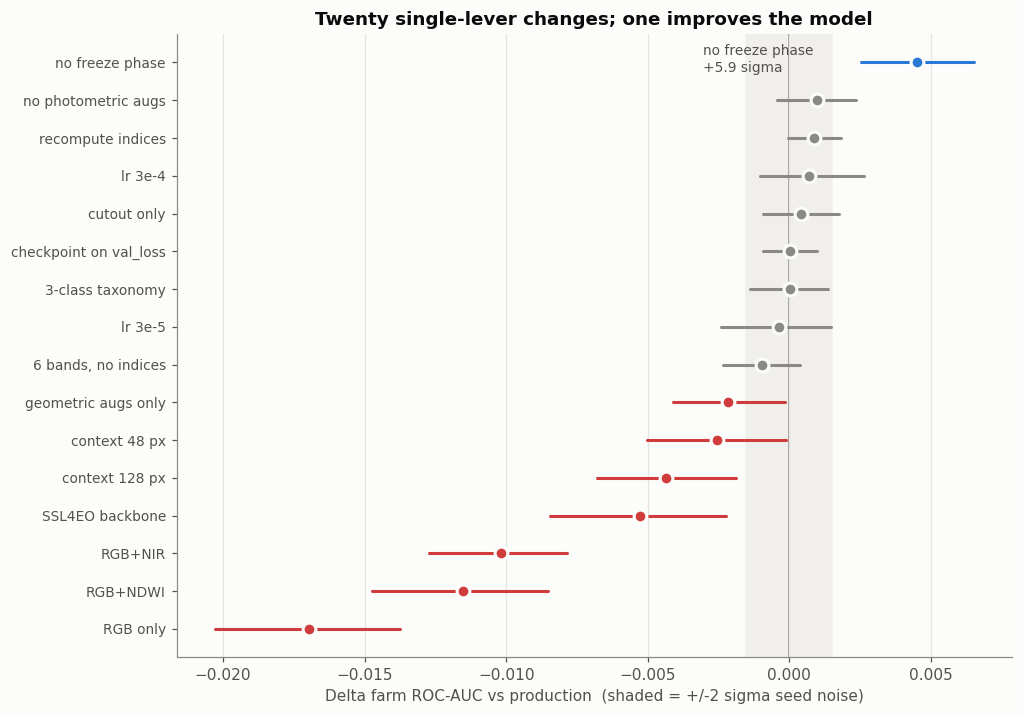

In [8]:
# Form: forest plot (dot + CI). Job is polarity + uncertainty per lever, so the
# diverging blue<->red pair encodes sign and the CI carries the uncertainty that
# a bar chart would throw away. Zero line + shaded noise band give the reference.
fig, ax = plt.subplots(figsize=(9.4, 6.6))
y = np.arange(len(lev))
band = 2*A["sigma_auc"]
ax.axvspan(-band, band, color=NEUTRAL, zorder=0)
ax.axvline(0, color=MUTED, lw=1, zorder=1)

for i, (_, r) in enumerate(lev.iterrows()):
    sig = abs(r["delta_auc"]) > band
    col = (BLUE if r["delta_auc"] > 0 else CRITICAL) if sig else MUTED
    ax.plot([r["lo"], r["hi"]], [i, i], color=col, lw=2, solid_capstyle="round", zorder=2)
    ax.scatter([r["delta_auc"]], [i], s=70, color=col, zorder=3,
               edgecolor="#fcfcfb", linewidth=2)

ax.set_yticks(y); ax.set_yticklabels(lev["desc"], fontsize=9)
ax.set_xlabel("Delta farm ROC-AUC vs production  (shaded = +/-2 sigma seed noise)")
ax.set_title("Twenty single-lever changes; one improves the model")
ax.grid(axis="y", visible=False)
ax.annotate("no freeze phase\n+5.9 sigma", xy=(lev["delta_auc"].max(), len(lev)-1),
            xytext=(-140, -6), textcoords="offset points", fontsize=9,
            color=INK2, ha="left")
plt.tight_layout(); plt.show()

Two results carry directly into the production recipe:

- **Removing the 5-epoch backbone freeze is the only measured improvement** (+0.0045
  AUC, 5.9σ; test macro-F1 +0.017, qual_eval +0.020) — and it shortens training.
- **The three spectral indices are dead weight**: six raw bands are indistinguishable
  from all nine channels, yet dropping to RGB+NIR costs 13σ. The SWIR bands carry real
  signal; NDVI/NDBI/NDWI carry none.

## 4. Per-slice view: in-domain gains that are transfer losses

The frozen benchmark answers farm-vs-not. Per-slice macro-F1 (Cattle excluded, since
§2 showed it is noise) shows *where* a lever helps — and larger context is the case
where those disagree.

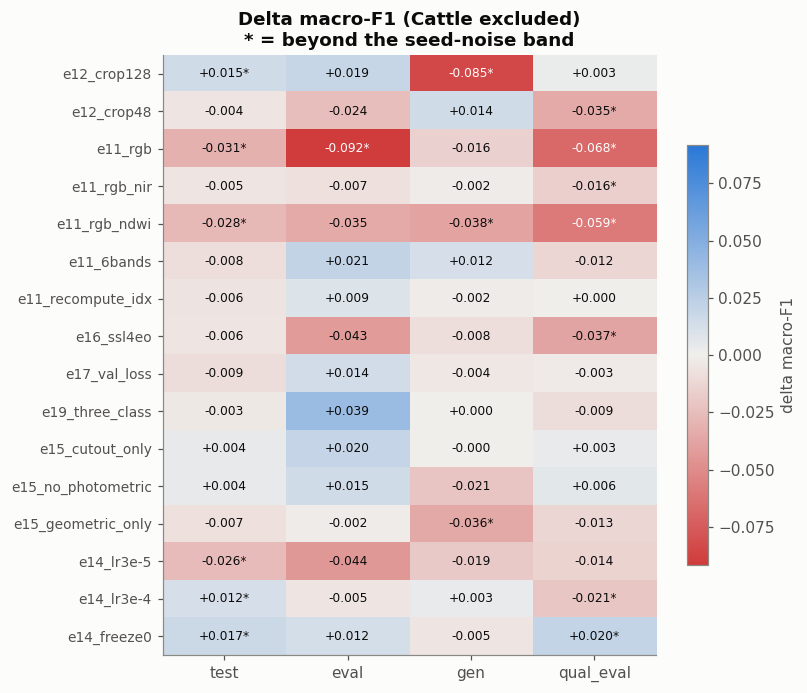

In [9]:
nc = pd.DataFrame([
    {"run": r["run"], **{k: r[k]["delta"] for k in ["test","eval","gen","qual_eval"] if k in r}}
    for r in A["per_slice_lever_verdicts_nocattle"]
]).set_index("run")
sig_nc = A["per_slice_sigma_nocattle"]

# Form: diverging heatmap. Job is polarity across a lever x slice matrix; the
# blue<->red pair with a neutral midpoint reads "better / nothing / worse".
fig, ax = plt.subplots(figsize=(7.4, 6.4))
cmap = mpl.colors.LinearSegmentedColormap.from_list("bwr_brand", [CRITICAL, NEUTRAL, BLUE])
vmax = float(np.nanmax(np.abs(nc.to_numpy())))
im = ax.imshow(nc.to_numpy(), cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_xticks(range(nc.shape[1])); ax.set_xticklabels(nc.columns)
ax.set_yticks(range(nc.shape[0])); ax.set_yticklabels(nc.index, fontsize=9)
for i in range(nc.shape[0]):
    for j in range(nc.shape[1]):
        v = nc.iat[i, j]
        if pd.isna(v): continue
        star = "*" if abs(v) > 2*np.sqrt(2)*sig_nc[nc.columns[j]] else ""
        ax.text(j, i, f"{v:+.3f}{star}", ha="center", va="center", fontsize=8,
                color=INK if abs(v) < vmax*0.55 else "#ffffff")
ax.set_title("Delta macro-F1 (Cattle excluded)\n* = beyond the seed-noise band")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="delta macro-F1")
plt.tight_layout(); plt.show()

`context 128 px` is the clearest case: **+0.015 on `test` but −0.085 on
`generalization`** (8.6σ). More context helps the model memorise the regions it
trained on and hurts transfer to unseen countries — the opposite of what a global
screening deployment needs. The production 64 px crop stands.

## 5. Post-hoc experiments (no GPU required)

These were answered by re-analysing archived model outputs.

In [10]:
thr = pd.DataFrame(load("e21_thresholds")["fixed_threshold_sweep"])
base = thr[thr.threshold == 0.5].iloc[0]
thr["d_recall"] = thr["recall"] - base["recall"]
thr["d_fpr"]    = thr["fpr"] - base["fpr"]
thr["rule"]     = np.where((thr.d_recall >= 0.05) & (thr.d_fpr <= 0.05), "PASS", "fail")
thr.loc[thr.threshold == 0.5, "rule"] = "default"
display(thr[["threshold","recall","fpr","precision","d_recall","d_fpr","rule"]]
        .style.format({"recall":"{:.3f}","fpr":"{:.3f}","precision":"{:.3f}",
                       "d_recall":"{:+.3f}","d_fpr":"{:+.3f}"}))

,threshold,recall,fpr,precision,d_recall,d_fpr,rule
0,0.200000,0.894,0.211,0.864,+0.129,+0.094,fail
1,0.300000,0.855,0.170,0.883,+0.090,+0.053,fail
2,0.400000,0.820,0.135,0.901,+0.055,+0.018,PASS
3,0.500000,0.765,0.117,0.907,+0.000,+0.000,default
4,0.600000,0.718,0.094,0.920,-0.047,-0.023,fail


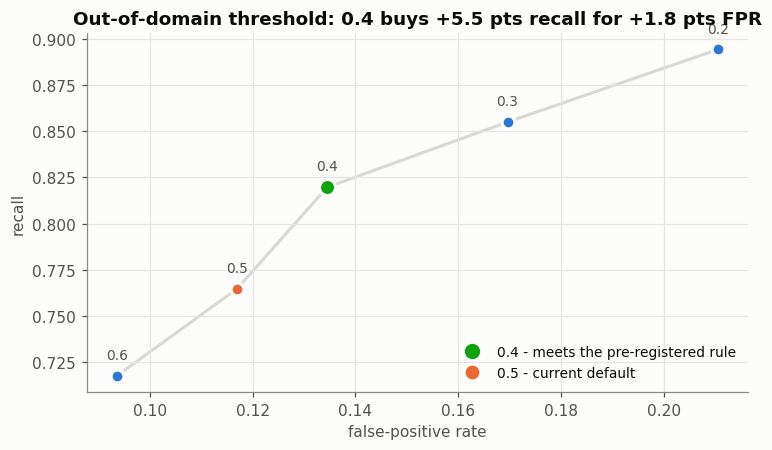

In [11]:
# Form: connected dot plot in recall/FPR space -- the trade-off IS the message,
# so both axes are the data and the threshold is the annotation.
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(thr["fpr"], thr["recall"], color="#d9d8d3", lw=2, zorder=1)
for _, r in thr.iterrows():
    pick = r["rule"] == "PASS"
    ax.scatter([r["fpr"]], [r["recall"]], s=110 if pick else 70,
               color=GOOD if pick else (ORANGE if r["rule"] == "default" else BLUE),
               zorder=3, edgecolor="#fcfcfb", linewidth=2)
    ax.annotate(f"{r['threshold']:.1f}", (r["fpr"], r["recall"]), xytext=(0, 11),
                textcoords="offset points", ha="center", fontsize=9, color=INK2)
ax.set_xlabel("false-positive rate"); ax.set_ylabel("recall")
ax.set_title("Out-of-domain threshold: 0.4 buys +5.5 pts recall for +1.8 pts FPR")
handles = [plt.Line2D([], [], marker="o", ls="", color=GOOD, markersize=9, label="0.4 - meets the pre-registered rule"),
           plt.Line2D([], [], marker="o", ls="", color=ORANGE, markersize=8, label="0.5 - current default")]
ax.legend(handles=handles, frameon=False, fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

In [12]:
leak = pd.DataFrame(load("e02_spatial_leakage")["inflation"])
display(leak[["split","n_near","auc_near","n_far","auc_far","auc_inflation","macroF1_inflation"]]
        .style.format({"auc_near":"{:.3f}","auc_far":"{:.3f}",
                       "auc_inflation":"{:+.3f}","macroF1_inflation":"{:+.3f}"}))

lab = load("e25_e26_balancing_labelsource")["e26"]["contrasts"]
print("\nLabel-source contrast (visual - registry), domain held constant:")
for c in lab:
    print(f"  {c['split']:<12} dAUC={c['visual_minus_registry_auc']:+.4f}  "
          f"dMacroF1={c['visual_minus_registry_macroF1']:+.4f}")

,split,n_near,auc_near,n_far,auc_far,auc_inflation,macroF1_inflation
0,val,866,0.993,1800,0.964,+0.028,+0.025
1,test,796,0.997,1298,0.992,+0.006,+0.023
2,eval,87,0.961,436,0.905,+0.056,+0.050
3,qual_eval,407,0.981,11365,0.983,-0.002,-0.028



Label-source contrast (visual - registry), domain held constant:
  eval         dAUC=-0.0909  dMacroF1=-0.1095
  qual_eval    dAUC=-0.0187  dMacroF1=-0.3226
  test         dAUC=-0.0433  dMacroF1=-0.2552
  train        dAUC=-0.0018  dMacroF1=-0.0926


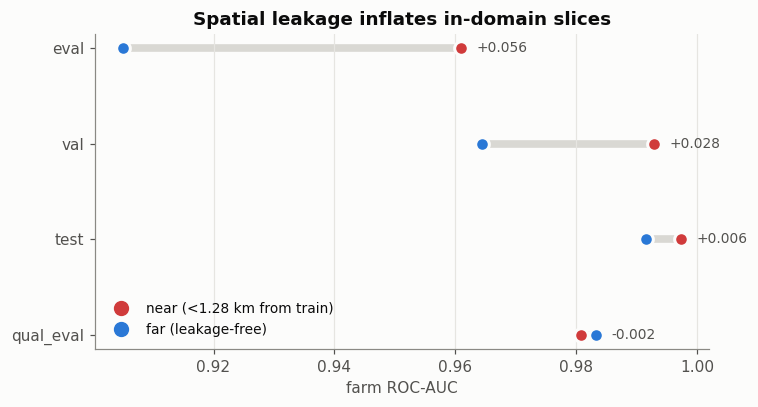

In [13]:
# Form: paired dot plot (slope). Job is a before/after comparison per split;
# the connecting line carries the size of the gap better than two bars.
fig, ax = plt.subplots(figsize=(7.0, 3.8))
lk = leak.sort_values("auc_inflation")
for i, (_, r) in enumerate(lk.iterrows()):
    ax.plot([r["auc_far"], r["auc_near"]], [i, i], color="#d9d8d3", lw=5,
            solid_capstyle="round", zorder=1)
    ax.scatter([r["auc_far"]], [i], s=80, color=BLUE, zorder=3, edgecolor="#fcfcfb", lw=2)
    ax.scatter([r["auc_near"]], [i], s=80, color=CRITICAL, zorder=3, edgecolor="#fcfcfb", lw=2)
    ax.annotate(f"{r['auc_inflation']:+.3f}", (max(r['auc_near'], r['auc_far']), i),
                xytext=(10, 0), textcoords="offset points", va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(lk))); ax.set_yticklabels(lk["split"])
ax.set_xlabel("farm ROC-AUC"); ax.grid(axis="y", visible=False)
ax.set_title("Spatial leakage inflates in-domain slices")
handles = [plt.Line2D([], [], marker="o", ls="", color=CRITICAL, markersize=9, label="near (<1.28 km from train)"),
           plt.Line2D([], [], marker="o", ls="", color=BLUE, markersize=9, label="far (leakage-free)")]
ax.legend(handles=handles, frameon=False, fontsize=9, loc="lower left")
plt.tight_layout(); plt.show()

## 6. Conclusions

**Measurement**
1. eval macro-F1 has σ = 0.033 (band ±0.095). Most historical verdicts sit inside it.
2. ~80% of that variance is the Cattle class with 6–7 held-out rows.
3. The frozen benchmark (n = 11,365) is σ = 0.0008 — use it, not `eval`.
4. It is powerful enough that trivial effects reach significance, so decision rules
   need a **practical floor**, not just a p-value.

**Production recipe — change these**
| Change | Evidence |
|---|---|
| `freeze_backbone_epochs: 0` | +0.0045 AUC, +5.9σ — the only win in 20 runs |
| drop NDVI/NDBI/NDWI (9→6 channels) | indistinguishable from 9ch; RGB+NIR is −13σ |
| merge/drop Cattle | 3-class is exactly 0.0000; removes the dominant noise source |
| OOD screening threshold 0.4 | +0.055 recall for +0.018 FPR (pre-registered rule) |

**Production recipe — confirmed as already correct**
64 px crop, lr 1e-4, SoftCon backbone, `val_f1` checkpointing, the full augmentation
stack, balancing off, no ensemble, no geometry fusion.

**Caveats**
- Levers were measured **individually**; composition is not assumed (SoftCon × ctx128
  failed to stack). The combination runs are still in flight.
- Augmentation was tested as *groups*, not per-term, and no augmentation
  hyperparameter (probability, magnitude) has been ablated.
- Candidate-stage recall remains unmeasured outside the reference region — a facility
  the morphometric filter never proposes is invisible to every number above.